## Importation des données

In [1]:
pip install ultralytics transformers numpy matplotlib torch torchvision scikit-learn seaborn tqdm

  Using cached ultralytics-8.4.21-py3-none-any.whl.metadata (39 kB)
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached torch-2.10.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using ca

In [9]:
import json
import os

chemin_annotations = os.path.join("dataset", "annotations.json")
dossier_images = os.path.join("dataset", "images")

classes_vues = [0, 1, 2, 3, 4]

with open(chemin_annotations, "r", encoding="utf-8") as fichier:
    donnees = json.load(fichier)

images_dict = {img["id"]: img["file_name"] for img in donnees.get("images", [])}
liste_annotations = donnees.get("annotations", donnees)

donnees_formatees = []

for item in liste_annotations:
    image_id = item.get("image_id")
    nom_fichier = images_dict.get(image_id, f"{image_id}.jpg")
    chemin_image = os.path.join(dossier_images, nom_fichier)
    
    bbox = item.get("bbox")
    classe = item.get("category_id", item.get("class_id"))
    statut = "seen" if classe in classes_vues else "unseen"
    
    donnees_formatees.append({
        "image": chemin_image,
        "bbox": bbox,
        "classe": classe,
        "statut": statut
    })

## YOLO

In [11]:
from ultralytics import YOLO

modele_yolo = YOLO("yolov8n.pt")

WARNING ⚠️ Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at '/Users/gaspardjuillet/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## OWL-ViT

Prompt Engineering

In [7]:
import json
import os
import tqdm
import torch
from PIL import Image
from transformers import OwlViTProcessor, OwlViTForObjectDetection


In [ ]:

print("Loading model and processor:")
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

model_id = "google/owlvit-base-patch32"
processor = OwlViTProcessor.from_pretrained(model_id)
model = OwlViTForObjectDetection.from_pretrained(model_id).to(device)
print("============================================")


In [16]:

def load_image(image_path):
    return Image.open(image_path).convert("RGB")

def load_annotations(annotation_path):
    with open(annotation_path, "r", encoding="utf-8") as f:
        return json.load(f)

# load all seen or unseen annotations from the json {classes: "seen": [bicyble, ...], "unseen": [...]}
def load_all_classes(annotations, seen=False):
    return annotations["classes"]["seen"] if seen else annotations["classes"]["unseen"]

def load_image_annotations(annotations, image_id, seen=False):
    ## find all annotation id that also have image_id
    annotation_data = [img for img in annotations["images"] if img["image_id"] == image_id]
    ##retrreive the metadata of the image with the image_id in images
    # image_metadata = next((img for img in annotations["images"] if img["id"] == image_id), None)
    
    return annotation_data

def load_image_metadata(annotations, image_id):
    return next((img for img in annotations["images"] if img["id"] == image_id), None)

def load_image_from_metadata(metadata):
    image_path = os.path.join("dataset/images", metadata["file_name"])
    return load_image(image_path)

def find_images_id_list(annotations, classes, seen=False):
    images_id_list = set()
    
    ## get a list of the image_id that have the category_id in the seen or unseen list
    for annotation in annotations["annotations"]:
        if annotation["category"] in classes:
            images_id_list.add(annotation["image_id"])
    
    return list(images_id_list)
        
def generate_texts_for_classes(classes):
    return [f"a photo of a {cls}" for cls in classes]


def run_inference_on_image(image, texts):
    inputs = processor(text=texts, images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
    
    target_sizes = torch.Tensor([image.size[::-1]])
    results = processor.post_process_grounded_object_detection(
        outputs=outputs, target_sizes=target_sizes, threshold=0.1
        )
    return results
     
def run_inference(annotation_path, seen=False):    
    print("Mode: ", "Seen" if seen else "Unseen")
    annotations = load_annotations(annotation_path)
    
    classes = load_all_classes(annotations, seen)
    print("Classes :", classes)
    
    texts = generate_texts_for_classes(classes)
    image_ids = find_images_id_list(annotations, classes, seen)
    print("Number of images to process: ", len(image_ids))
    
    inference_results = {}
    for image_id in tqdm.tqdm(image_ids[:2]):
        image_metadata = load_image_metadata(annotations, image_id)
        image = load_image_from_metadata(image_metadata)
        # annotation_data = load_image_annotations(annotations, image_id, seen)
        if image_metadata is not None:
            image_path = os.path.join("dataset/images", image_metadata["file_name"])
            image = load_image(image_path)
            
            ## show image
            image.show()
            results = run_inference_on_image(image, texts)
            
            inference_results[image_id] = results
    return inference_results

annotation_path = "dataset/annotations.json"
inference_results = run_inference(annotation_path, seen=True)
print(inference_results)
# boxes, scores, labels = results[i]["boxes"], results[i]["scores"], results[i]["labels"]

# for box, score, label in zip(boxes, scores, labels):
#     box = [round(i, 2) for i in box.tolist()]
#     print(f"Detected {texts[0][label]} with confidence {round(score.item(), 3)} at {box}")

Mode:  Seen
Classes : ['Bicycle', 'Dog', 'Pizza', 'Bus', 'Chair']
Number of images to process:  129


100%|██████████| 2/2 [00:02<00:00,  1.24s/it]

{'947a61e750f23ce9': [{'scores': tensor([0.4313, 0.1875, 0.1220, 0.1601, 0.4959, 0.1477, 0.4889, 0.3751, 0.5907,
        0.1163, 0.5825, 0.6518, 0.1042, 0.1010], device='mps:0'), 'labels': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='mps:0'), 'boxes': tensor([[ 3.9518e+02,  3.1355e+02,  5.3102e+02,  5.0683e+02],
        [ 3.0138e-01,  3.1874e+02,  1.1033e+02,  5.2184e+02],
        [ 1.3330e+01,  3.2729e+02,  1.9797e+02,  5.3740e+02],
        [ 8.8756e+01,  3.2869e+02,  2.1347e+02,  5.2245e+02],
        [ 4.0943e+02,  3.1715e+02,  5.5911e+02,  5.1083e+02],
        [ 4.1665e+02,  3.1302e+02,  5.5266e+02,  5.1268e+02],
        [ 4.8118e+02,  3.0627e+02,  6.4898e+02,  5.4458e+02],
        [ 5.2114e+02,  3.1941e+02,  6.8507e+02,  5.5898e+02],
        [-3.9482e-02,  3.2168e+02,  1.7443e+02,  5.5645e+02],
        [ 5.1914e+02,  3.3706e+02,  6.6285e+02,  5.3865e+02],
        [ 2.4844e+02,  3.5718e+02,  4.4008e+02,  6.1855e+02],
        [ 5.9833e+02,  3.6784e+02,  8.4264e+02,  6.4

Detected a with confidence 0.591 at [-0.04, 321.68, 174.43, 556.45]
Detected a with confidence 0.582 at [248.44, 357.18, 440.08, 618.55]
Detected a with confidence 0.652 at [598.33, 367.84, 842.64, 647.21]
GT BOX:  [0.0, 0.47345132, 0.100294985, 0.33849558]
GT BOX:  [0.050147492, 0.460177, 0.14011799800000002, 0.30088497]
GT BOX:  [0.2359882, 0.460177, 0.579646, 0.4845133]
GT BOX:  [0.9454277, 0.6261062, 0.05457230000000002, 0.3252212400000001]
GT BOX:  [0.02359882, 0.25, 0.03982301, 0.11504424000000002]
GT BOX:  [0.09882006, 0.26548672, 0.04867257000000001, 0.09292035999999998]
GT BOX:  [0.2979351, 0.24778761, 0.05752212000000001, 0.12831859]
GT BOX:  [0.4380531, 0.29646018, 0.044247780000000014, 0.09955751999999995]
GT BOX:  [0.56047195, 0.19247788, 0.06342185, 0.11725664000000002]
GT BOX:  [0.6784661, 0.28761062, 0.06342180000000008, 0.13274336000000003]


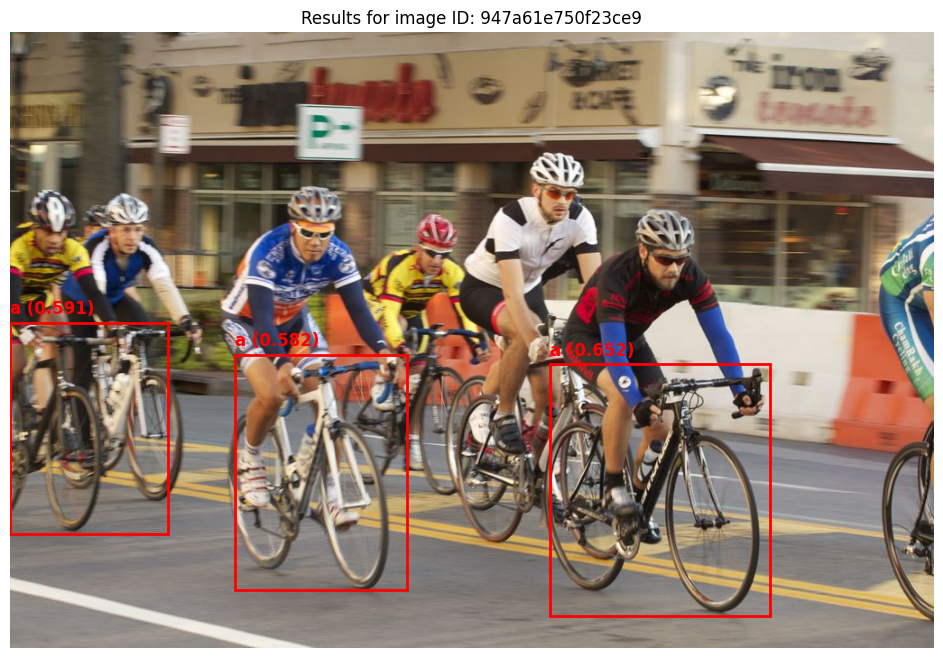

Detected p with confidence 0.749 at [28.01, 102.77, 987.42, 913.13]
GT BOX:  [0.03068592, 0.1064982, 0.9314079799999999, 0.7725632]


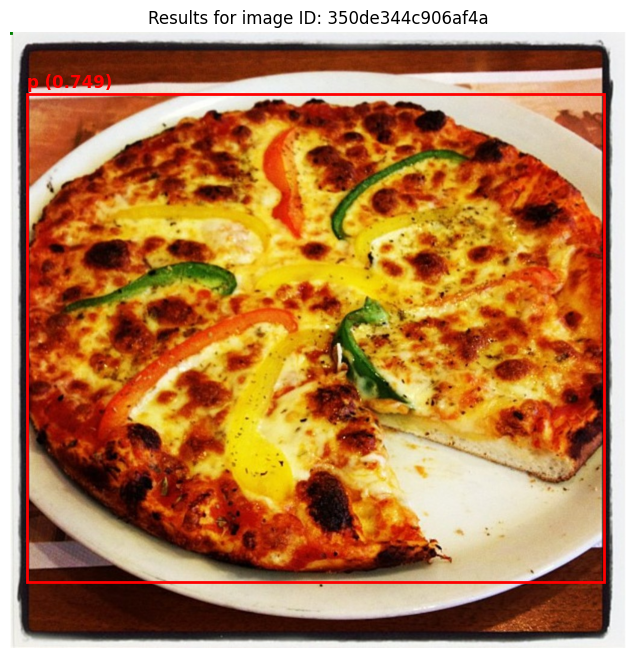

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def show_results_on_image(image_id, inference_results, texts, threshold=0.5):
    image_metadata = load_image_metadata(annotations, image_id)
    image = load_image_from_metadata(image_metadata)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    ax = plt.gca()
    
    ## find the image_id in the inference_results then plot
    results = inference_results.get(image_id, [])
    
    ## process the results (bboxes and labels and scores)
    for result in results:
        boxes, scores, labels = result["boxes"], result["scores"], result["labels"]
        for box, score, label in zip(boxes, scores, labels):
            if score.item() < threshold:
                continue
            box = [round(i, 2) for i in box.tolist()]
            confidence = round(score.item(), 3)
            class_name = texts[0][label]
            print(f"Detected {class_name} with confidence {confidence} at {box}")
            
            ## plot the box on the image
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            plt.text(box[0], box[1] - 10, f"{class_name} ({confidence})", 
                     color='red', fontsize=12, weight='bold')
            
    ## draw the gt too (in green), but before convert to image coordinates
    # TODO see above
    for annotation in annotations["annotations"]:
        if annotation["image_id"] == image_id:
            gt_box = annotation["bbox"]
            print("GT BOX: ", gt_box)
            rect = patches.Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1], 
                                     linewidth=2, edgecolor='g', facecolor='none')
            ax.add_patch(rect)
    plt.title(f"Results for image ID: {image_id}")
    plt.axis('off')
    plt.show()
    
image_id = "947a61e750f23ce9"
annotations = load_annotations(annotation_path)
texts = generate_texts_for_classes(load_all_classes(annotations, seen=True))
show_results_on_image(image_id, inference_results, texts)

image_id = "350de344c906af4a"
show_results_on_image(image_id, inference_results, texts)

In [25]:
import numpy as np

## compute metrics: precision, recall, f1-score, mAP
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    
    iou = interArea / float(boxAArea + boxBArea - interArea)
    
    return iou

## collect class results and annotations
def load_one_class_res_and_gt(inference_results, annotations, class_name):
    predictions = []
    ground_truths = []
    for image_id, results in inference_results.items():
        for result in results:
            boxes, scores, labels = result["boxes"], result["scores"], result["labels"]
            for box, score, label in zip(boxes, scores, labels):
                if score.item() < 0.5:
                    continue
                if texts[0][label] == class_name:
                    predictions.append((image_id, box.tolist(), score.item()))
                    
    for annotation in annotations["annotations"]:
        if annotation["category"] == class_name:
            ground_truths.append((annotation["image_id"], annotation["bbox"]))
    
    return predictions, ground_truths

def compute_fp_tp_fn_one_class(predictions, ground_truths, iou_threshold=0.3):
    # compute tp, fp, fn
    # sort predictions by confidence score
    predictions.sort(key=lambda x: x[2], reverse=True)
    tp = 0
    fp = 0
    fn = len(ground_truths)
    matched_gt = set()
    for pred in predictions:
        pred_image_id, pred_box, pred_score = pred
        best_iou = 0
        best_gt_idx = -1
        for gt_idx, gt in enumerate(ground_truths):
            gt_image_id, gt_box = gt
            if gt_image_id != pred_image_id or gt_idx in matched_gt:
                continue
            
            #compute iou
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1
    fn -= tp
    return tp, fp, fn

def compute_basic_metrics(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1_score

def compute_AP_for_one_class(predictions, ground_truths, iou_threshold=0.5):
    # compute mAP for one class
    predictions.sort(key=lambda x: x[2], reverse=True)
    tp = []
    fp = []
    matched_gt = set()
    
    for pred in predictions:
        pred_image_id, pred_box, pred_score = pred
        best_iou = 0
        best_gt_idx = -1
        for gt_idx, gt in enumerate(ground_truths):
            gt_image_id, gt_box = gt
            if gt_image_id != pred_image_id or gt_idx in matched_gt:
                continue
            
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold:
            tp.append(1)
            fp.append(0)
            matched_gt.add(best_gt_idx)
        else:
            tp.append(0)
            fp.append(1)
    
    # compute precision-recall curve
    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)
    
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
    recalls = tp_cumsum / (len(ground_truths) + 1e-6)
    
    # compute AP using the precision-recall curve
    ap = 0
    for i in range(len(precisions)):
        if recalls[i] > 0:
            ap += precisions[i] * (recalls[i] - recalls[i-1])
    
    return ap

def compute_mAP(inference_results, annotations, classes, iou_threshold=0.5):
    ap_per_class = {}
    for class_name in classes:
        predictions, ground_truths = load_one_class_res_and_gt(inference_results, annotations, class_name)
        ap = compute_AP_for_one_class(predictions, ground_truths, iou_threshold)
        ap_per_class[class_name] = ap
    mAP = np.mean(list(ap_per_class.values()))
    return mAP, ap_per_class

def compute_all_metrics(inference_results, annotations, classes, iou_threshold=0.5):
    ## compute all metrics for each class and average and mAP (also return AP)
    metrics_per_class = {}
    for class_name in classes:
        predictions, ground_truths = load_one_class_res_and_gt(inference_results, annotations, class_name)
        tp, fp, fn = compute_fp_tp_fn_one_class(predictions, ground_truths, iou_threshold)
        precision, recall, f1_score = compute_basic_metrics(tp, fp, fn)
        ap = compute_AP_for_one_class(predictions, ground_truths, iou_threshold)
        metrics_per_class[class_name] = {
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score,
            "AP": ap
        }
    mAP = np.mean([metrics["AP"] for metrics in metrics_per_class.values()])
    return metrics_per_class, mAP

def display_metrics(metrics_per_class, mAP):
    print(f"mAP: {mAP:.4f}")
    for class_name, metrics in metrics_per_class.items():
        print(f"Class: {class_name}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-Score: {metrics['f1_score']:.4f}")
        print(f"  AP: {metrics['AP']:.4f}")

classes = load_all_classes(annotations, seen=True)
metrics_per_class, mAP = compute_all_metrics(inference_results, annotations, classes)
display_metrics(metrics_per_class, mAP)

mAP: 0.0000
Class: Bicycle
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AP: 0.0000
Class: Dog
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AP: 0.0000
Class: Pizza
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AP: 0.0000
Class: Bus
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AP: 0.0000
Class: Chair
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AP: 0.0000
